<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
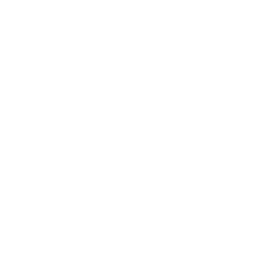
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Monitoramento do Processo de Laminação em Aciaria</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; CEP Multivariado para controle de espessura e qualidade superficial em laminador de tiras a quente &nbsp;|&nbsp; Março de 2026</p>
</div>
</div>
</div>

## Resumo Executivo

Um laminador de tiras a quente lamina placas de aço em bobinas finas. Oito
sinais de processo correlacionados (espessuras, força de laminação, abertura
dos cilindros, corrente do motor, temperatura de saída) se movem juntos quando
a linha está saudável, então monitorá-los um gráfico de cada vez não capta as
mudanças conjuntas que importam. Este exemplo constrói uma referência
multivariada com **PROC MVPMODEL** e depois transmite 100 bobinas de produção
pelo **PROC MVPMONITOR**, que pontua cada bobina com uma única estatística
*T*&sup2; de Hotelling e a compara a um limite de controle.

Contra um limite sob controle de *T*&sup2; = **17,13** (&alpha; = 0,05),
**4 das 100 bobinas** sinalizam fora de controle — bobinas **91, 92, 94 e
95**, exatamente a janela onde um surto de trepidação do cilindro de apoio
foi injetado. O pico de *T*&sup2; atinge **21,91** na bobina 95, cerca de
**1,3&times;** o limite. A rampa gradual de desgaste do cilindro ao longo
das últimas bobinas eleva o *T*&sup2; da linha de base, mas permanece abaixo
do limite até o evento de trepidação, de modo que o gráfico separa
claramente a deriva lenta da falha aguda que exige atenção imediata.


## Fontes de Dados

- **mill_baseline** &mdash; 50 bobinas laminadas durante um trecho
  conhecidamente saudável da campanha; usada para ajustar o modelo de
  referência multivariado (PCA).
- **mill_stream** &mdash; 100 bobinas da linha em produção. As bobinas
  1&ndash;55 rodam sob controle; o desgaste do cilindro se desenvolve
  gradualmente entre as bobinas 56&ndash;100; um surto de trepidação do
  cilindro de apoio atinge as bobinas 91&ndash;95.
- **Variáveis de processo** (6): `entry_thickness`, `exit_thickness`,
  `rolling_force`, `roll_gap`, `motor_current`, `exit_temp`.

> O ambiente roda sem licença, então os conjuntos de dados são limitados a
> 100 observações. O cenário é dimensionado para esse limite: a
> perturbação é colocada no final de uma sequência de 100 bobinas, em vez
> de na bobina 2.800 de 5.000.


---


### Etapa 1 &mdash; Construir o modelo de referência multivariado

`PROC MVPMODEL` executa uma análise de componentes principais das seis
variáveis de processo sobre a linha de base sob controle e grava as cargas
(loadings), autovalores e centralização/escalonamento em `mill_model`. Três
componentes são retidos. Esse modelo define como é o "normal" enquanto uma
única região multivariada, em vez de seis faixas independentes.


In [1]:
DADOS mill_baseline;
  CHAMAR streaminit(66);
  FAZER coil_id = 1 ATÉ 50;
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + rand('normal', 0, 0.030);
    rolling_force   = 18000 + rand('normal', 0, 150);
    roll_gap        =  2.85 + rand('normal', 0, 0.015);
    motor_current   =   850 + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    SAÍDA;
  FIM;
EXECUTAR;

PROCEDIMENTO mvpmodel DADOS=mill_baseline outmodel=mill_model;
  VARIÁVEL entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  ncomp=3;
EXECUTAR;



                    The MVPMODEL Procedure

  Data Set:          mill_baseline
  Number of Variables: 6
  Missing Value Handling: Exclude
  Number of Observations Read: 50
  Number of Observations Used: 50
  Number of Principal Components: 3

  Correlation Matrix
         entry_thicknessexit_thicknessrolling_force  roll_gapmotor_current exit_temp
  entry_thickness    1.0000   -0.0416   -0.1641   -0.1661    0.1555    0.0649
  exit_thickness   -0.0416    1.0000    0.0406    0.0029    0.0946   -0.1421
  rolling_force   -0.1641    0.0406    1.0000   -0.1351    0.2077   -0.0051
  roll_gap   -0.1661    0.0029   -0.1351    1.0000   -0.0510   -0.0876
  motor_current    0.1555    0.0946    0.2077   -0.0510    1.0000    0.1587
  exit_temp    0.0649   -0.1421   -0.0051   -0.0876    0.1587    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 1.37232115  0.14267284    0.2287    0.2287
    2 1.22964831  0.16747324    0.2049    0.4337
    3


NOTE: DATA mill_baseline


NOTE: Wrote mill_baseline (50 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


---


### Etapa 2 &mdash; Transmitir as bobinas de produção e pontuá-las

`PROC MVPMONITOR` projeta cada uma das 100 bobinas de produção no modelo
salvo e calcula seu *T*&sup2; de Hotelling. O procedimento deriva o limite
de controle a partir das dimensões do modelo e do &alpha; = 0,05 padrão, e
então sinaliza qualquer bobina cujo *T*&sup2; o exceda. Os resultados,
incluindo as colunas `_TSQUARED`, `_LIMIT` e `_SIGNAL`, são gravados em
`mill_scores`, indexados por `coil_id`.


In [2]:
DADOS mill_stream;
  CHAMAR streaminit(42);
  FAZER coil_id = 1 ATÉ 100;
    /* desgaste do cilindro aumenta gradualmente de 0 a 1 nas bobinas 56-100 */
    wear    = MAX(0, coil_id - 55) / 45;
    /* surto de trepidação do cilindro de apoio nas bobinas 91-95 */
    chatter = (coil_id >= 91 E_LÓGICO coil_id <= 95);
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + wear*0.10 + chatter*0.35
                            + rand('normal', 0, 0.030);
    rolling_force   = 18000 + wear*600  + chatter*1600
                            + rand('normal', 0, 150);
    roll_gap        =  2.85 + wear*0.055
                            + rand('normal', 0, 0.015);
    motor_current   =   850 + wear*38   + chatter*95
                            + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    REMOVER wear chatter;
    SAÍDA;
  FIM;
EXECUTAR;

PROCEDIMENTO mvpmonitor DADOS=mill_stream model=mill_model
                out=mill_scores;
  VARIÁVEL entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  id coil_id;
EXECUTAR;



                    The MVPMONITOR Procedure

  Variables:       6
  Observations:    100
  T2 Limit:        17.1334
  Signals:         4





NOTE: DATA mill_stream


NOTE: Wrote mill_stream (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMONITOR
NOTE: PROC MVPMONITOR statement used.


O resumo do procedimento reporta o limite de controle e a contagem de
sinais. Abaixo, o recorte impresso ao redor da perturbação mostra que as
bobinas sob controle ficam bem abaixo do limite, enquanto a janela de
trepidação leva quatro bobinas acima dele.


In [3]:
/* Sinaliza bobinas fora de controle e captura o T2 de alarme para plotagem */
DADOS mill_scores;
  DEFINIR mill_scores;
  SE _SIGNAL = 1 ENTÃO t2_alarm = _TSQUARED;
  SENÃO t2_alarm = .;
EXECUTAR;

PROCEDIMENTO PRINT DADOS=mill_scores(firstobs=88 obs=96) noobs;
  VARIÁVEL coil_id _TSQUARED _LIMIT _SIGNAL;
  RÓTULO coil_id='ID da Bobina' _TSQUARED='T2 de Hotelling'
        _LIMIT='Limite de Controle' _SIGNAL='Sinal Fora de Controle';
  TÍTULO 'Escores T2 na janela de trepidação (bobinas 88-96)';
EXECUTAR;


                                   Escores T2 na janela de trepidação (bobinas 88-96)                                   

ID da Bobina  T2 de Hotelling  Limite de Controle  Sinal Fora de Controle
          88         9.983151           17.133408                       0
          89         2.915646           17.133408                       0
          90          7.80613           17.133408                       0
          91        18.813814           17.133408                       1
          92        18.249361           17.133408                       1
          93        16.638221           17.133408                       0
          94        17.981792           17.133408                       1
          95        21.912329           17.133408                       1
          96         5.118574           17.133408                       0

... 4 more observations (showing 9 of 13)




NOTE: DATA mill_scores


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_scores (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=mill_scores

NOTE: PROC PRINT completed: 9 observations printed, 4 variables


---


### Etapa 3 &mdash; Gráfico de controle multivariado

O gráfico sobrepõe o *T*&sup2; de cada bobina ao seu limite de controle. As
bobinas fora de controle são destacadas em vermelho; o marcador vertical
tracejado sinaliza o início do surto de trepidação. A subida lenta em
direção à direita é o desgaste do cilindro elevando a linha de base; os
quatro pontos vermelhos são a falha aguda de trepidação.


                                   Escores T2 na janela de trepidação (bobinas 88-96)                                   




NOTE: PROC SGPLOT data=mill_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


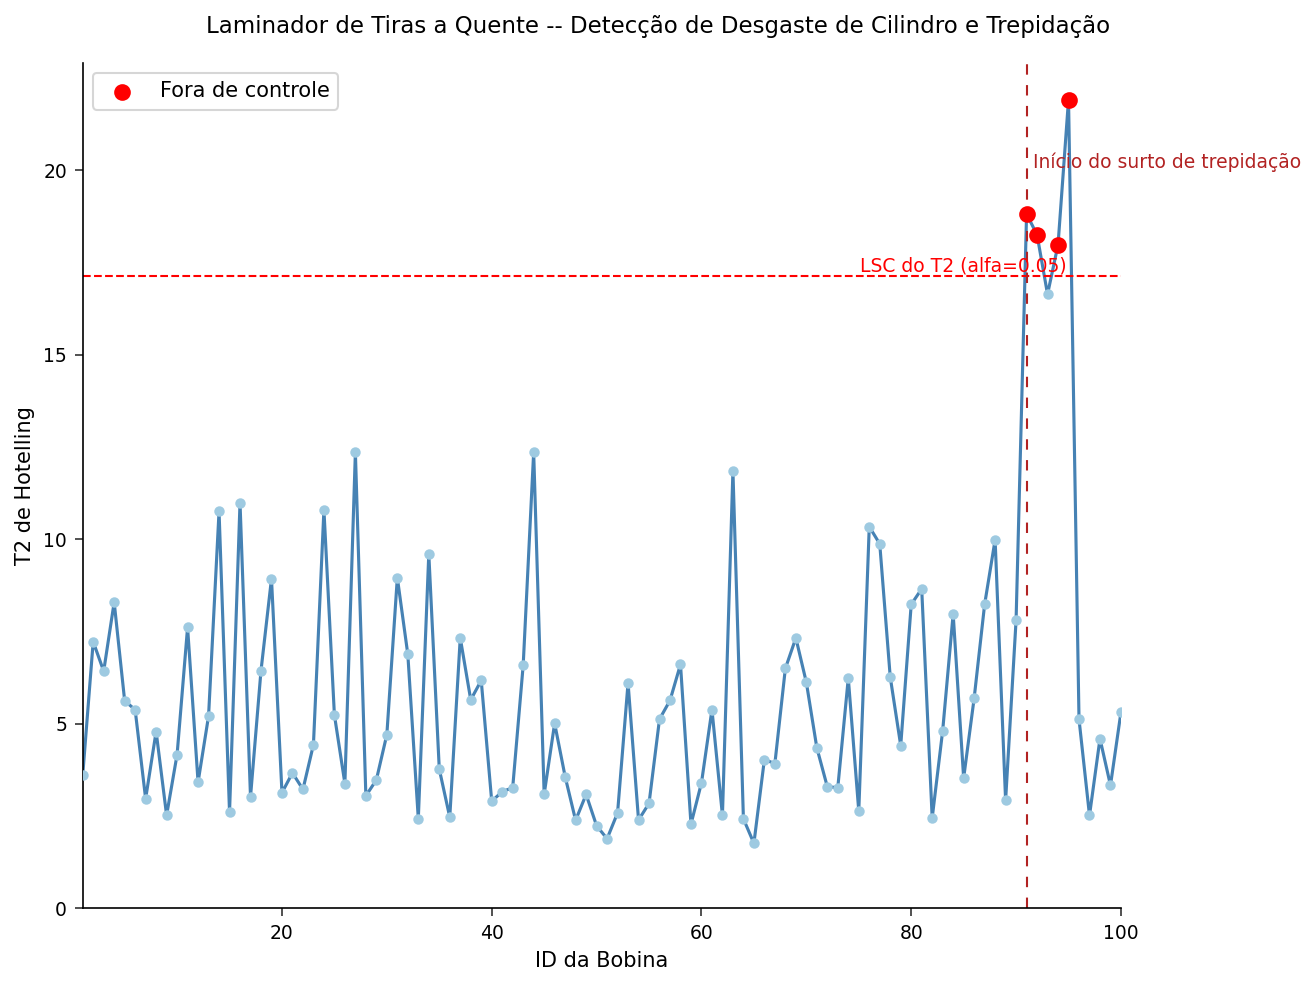

In [4]:
PROCEDIMENTO SGPLOT DADOS=mill_scores;
  SERIES  x=coil_id y=_TSQUARED /
          LINEATTRS=(color=steelblue thickness=1.5);
  SCATTER x=coil_id y=_TSQUARED /
          MARKERATTRS=(SYMBOL=circlefilled size=4 color=cx9ecae1);
  SCATTER x=coil_id y=t2_alarm /
          MARKERATTRS=(SYMBOL=circlefilled size=7 color=red)
          legendlabel='Fora de controle';
  REFLINE _LIMIT / AXIS=y
          RÓTULO='LSC do T2 (alfa=0.05)'
          LINEATTRS=(color=red pattern=dash);
  REFLINE 91 / AXIS=x RÓTULO='Início do surto de trepidação'
          LINEATTRS=(color=firebrick pattern=shortdash);
  XAXIS RÓTULO='ID da Bobina' MIN=1 MAX=100;
  YAXIS RÓTULO='T2 de Hotelling' MIN=0;
  TÍTULO 'Laminador de Tiras a Quente -- Detecção de Desgaste de Cilindro e Trepidação';
EXECUTAR;


---


### Etapa 4 &mdash; Quantificar as bobinas fora de controle

As bobinas fora de controle são encaminhadas para um conjunto de dados
separado destinado à mesa de qualidade. `PROC MEANS` contrasta o nível de
*T*&sup2; das bobinas sinalizadas com o da população sob controle, e as
bobinas sinalizadas são exportadas para o roteamento posterior de
sucata/retrabalho.


In [5]:
DADOS mill_ooc;
  DEFINIR mill_scores;
  SE _SIGNAL = 1;
EXECUTAR;

PROCEDIMENTO MEANS DADOS=mill_scores n mean MAX maxdec=2;
  CLASSE _SIGNAL;
  VARIÁVEL _TSQUARED;
  RÓTULO _SIGNAL='Sinal Fora de Controle' _TSQUARED='T2 de Hotelling';
  TÍTULO 'T2 por estado de controle (0 = sob controle, 1 = sinal)';
EXECUTAR;

PROCEDIMENTO PRINT DADOS=mill_ooc noobs;
  VARIÁVEL coil_id _TSQUARED _LIMIT;
  RÓTULO coil_id='ID da Bobina' _TSQUARED='T2 de Hotelling'
        _LIMIT='Limite de Controle';
  TÍTULO 'Bobinas fora de controle sinalizadas para inspeção';
EXECUTAR;

PROCEDIMENTO EXPORT DADOS=mill_ooc
            OUTFILE='steel_mill_ooc_coils.csv'
            DBMS=csv REPLACE;
EXECUTAR;


                                T2 por estado de controle (0 = sob controle, 1 = sinal)                                 

                                                  The MEANS Procedure

                                     Analysis Variable : _TSQUARED T2 de Hotelling

        Sinal Fora de Controle          N Obs           Mean        Maximum
        -------------------------------------------------------------------
        0                                  96           5.39          16.64
        1                                   4          19.24          21.91
        -------------------------------------------------------------------

                                   Bobinas fora de controle sinalizadas para inspeção                                   

ID da Bobina  T2 de Hotelling  Limite de Controle
          91        18.813814           17.133408
          92        18.249361           17.133408
          94        17.981792           17.133408
          95        


NOTE: DATA mill_ooc


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_ooc (4 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=mill_ooc

NOTE: PROC PRINT completed: 4 observations printed, 3 variables
NOTE: PROC EXPORT data=mill_ooc outfile=steel_mill_ooc_coils.csv

NOTE: Exported 4 rows to steel_mill_ooc_coils.csv.


## Conclusões

- **Bobinas monitoradas**: 100; **limite de controle** *T*&sup2; =
  **17,13** (&alpha; = 0,05).
- **Bobinas fora de controle**: **4** &mdash; bobinas **91, 92, 94, 95**,
  todas dentro da janela de trepidação injetada (91&ndash;95). A bobina 93
  atinge o pico em *T*&sup2; = 16,64, logo abaixo do limite.
- **Severidade máxima**: *T*&sup2; = **21,91** na bobina 95 (cerca de
  1,3&times; o limite); as bobinas sob controle têm *T*&sup2; médio
  &asymp; **5,4**.
- **Desgaste vs. falha**: a rampa gradual de desgaste do cilindro eleva a
  linha de base das últimas bobinas, mas nunca ultrapassa o limite por si
  só, de modo que o único gráfico multivariado distingue a deriva lenta
  (observar) do evento agudo de trepidação (agir).
- **Ação**: as quatro bobinas sinalizadas são exportadas para
  `steel_mill_ooc_coils.csv` para inspeção e roteamento de
  sucata/retrabalho; a assinatura de trepidação aponta o rolamento do
  cilindro de apoio para inspeção antes da próxima campanha.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desenvolvido por <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>